# Setting

### Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스

### Load data

In [3]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
file_list = glob.glob(os.path.join(path, '20*.csv'))

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

찾은 CSV 파일 개수: 8
파일 목록: ['./Data/2020.csv', './Data/2021.csv', './Data/2023.csv', './Data/2022.csv', './Data/2025.csv', './Data/2019.csv', './Data/2018.csv', './Data/2024.csv']

통합된 데이터프레임 크기: (4005951, 30)


### Data Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005951 entries, 0 to 4005950
Data columns (total 30 columns):
 #   Column     Dtype  
---  ------     -----  
 0   접수년도       int64  
 1   자치구코드      float64
 2   자치구명       object 
 3   법정동코드      float64
 4   법정동명       object 
 5   지번구분코드     float64
 6   지번구분       object 
 7   본번         float64
 8   부번         float64
 9   층          float64
 10  계약일        int64  
 11  전월세구분      object 
 12  임대면적       float64
 13  보증금(만원)    int64  
 14  임대료(만원)    int64  
 15  건물명        object 
 16  건축년도       float64
 17  건물용도       object 
 18  계약기간       object 
 19  신규계약구분     object 
 20  갱신청구권사용    object 
 21  종전보증금      float64
 22  종전임대료      float64
 23  지번구분명      object 
 24  전월세 구분     object 
 25  임대면적(㎡)    float64
 26  신규갱신여부     object 
 27  계약갱신권사용여부  object 
 28  종전 보증금     float64
 29  종전 임대료     float64
dtypes: float64(13), int64(4), object(13)
memory usage: 916.9+ MB


In [5]:
df['접수년도'].unique()

array([2020, 2021, 2023, 2022, 2025, 2019, 2018, 2024])

In [6]:
print("--- DataFrame의 실제 컬럼명 ---")
print(df.columns)

--- DataFrame의 실제 컬럼명 ---
Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료', '지번구분명',
       '전월세 구분', '임대면적(㎡)', '신규갱신여부', '계약갱신권사용여부', '종전 보증금', '종전 임대료'],
      dtype='object')


In [7]:
print(df.head(5))

   접수년도    자치구코드 자치구명    법정동코드   법정동명  지번구분코드 지번구분      본번    부번     층  ...  \
0  2020  11170.0  용산구  11300.0  원효로2가     1.0   대지     1.0   0.0   6.0  ...   
1  2020  11440.0  마포구  11000.0   노고산동     1.0   대지     1.0   1.0   9.0  ...   
2  2020  11440.0  마포구  11000.0   노고산동     1.0   대지     1.0   1.0  10.0  ...   
3  2020  11590.0  동작구  10700.0    사당동     1.0   대지  1007.0  19.0   7.0  ...   
4  2020  11590.0  동작구  10700.0    사당동     1.0   대지  1007.0  19.0   3.0  ...   

   갱신청구권사용 종전보증금  종전임대료  지번구분명  전월세 구분 임대면적(㎡)  신규갱신여부 계약갱신권사용여부 종전 보증금 종전 임대료  
0      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
1      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
2      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
3      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
4      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  

[5 rows x 30 columns]


# Data Cleaning & Preparation

In [8]:
# 필요한 데이터 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df = df[selected_columns]
print(df.head(3))

   접수년도 자치구명   법정동명 전월세구분   임대면적  보증금(만원)  임대료(만원)  건물용도
0  2020  용산구  원효로2가    전세  22.03     5000        0  오피스텔
1  2020  마포구   노고산동    전세  33.66    18500        0  오피스텔
2  2020  마포구   노고산동    전세  41.04    22000        0  오피스텔


In [9]:
# 법정동명 확인
#print(df['법정동명'].unique())

# 원하는 동이 있는지 확인
target_dong = '합정동'
if target_dong in df['법정동명'].values:
    print(f"'{target_dong}' 동이 데이터에 존재합니다.")
else:
    print(f"'{target_dong}' 동이 데이터에 존재하지 않습니다.")

'합정동' 동이 데이터에 존재합니다.


In [10]:
# 결측치 및 이상치 처리
print(df.isnull().sum())
df = df.dropna()
df = df[df['임대면적'] > 0]

접수년도            0
자치구명            3
법정동명            3
전월세구분      448204
임대면적       448195
보증금(만원)         0
임대료(만원)         0
건물용도            0
dtype: int64


### 임대면적 분포

Text(0.5, 1.0, '임대면적 분포')

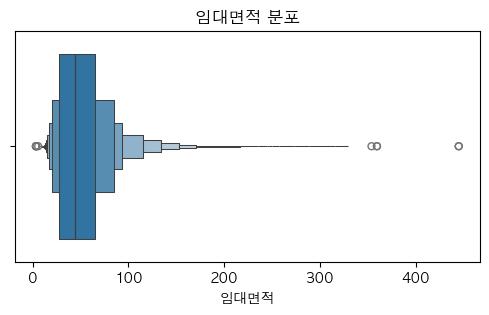

In [11]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포')

Text(0.5, 1.0, '임대면적 분포 (이상치 제거 후)')

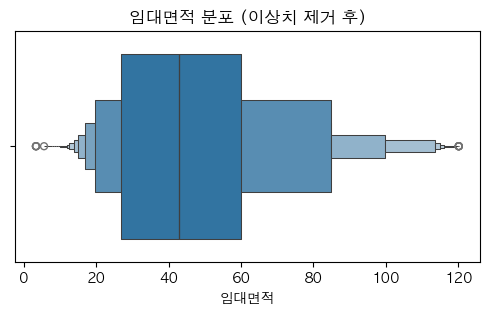

In [12]:
# 이상치 제거
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포 (이상치 제거 후)')

### 입대료 분포


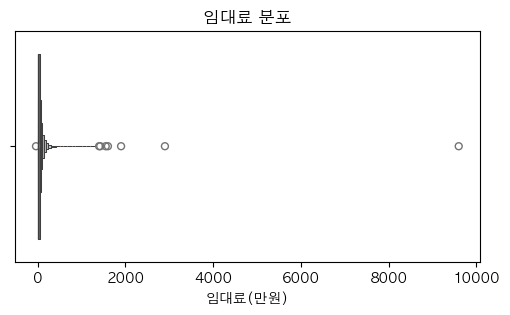

In [13]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포')
plt.show()

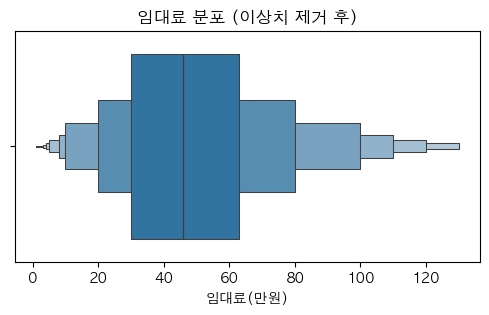

In [14]:
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

### 보증금 분포

Text(0.5, 1.0, '보증금 분포')

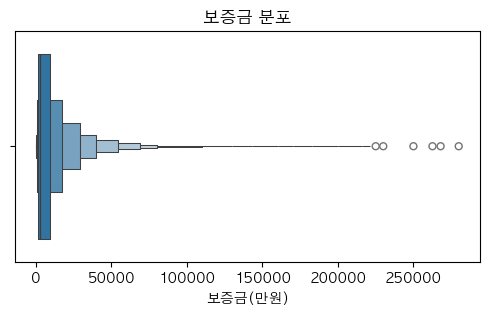

In [15]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포')

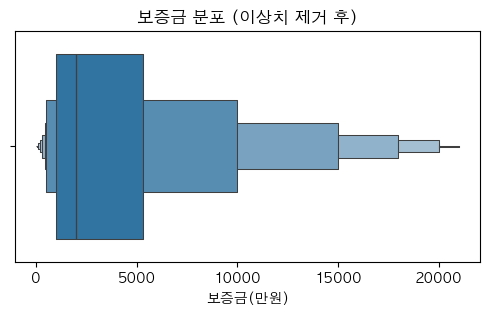

In [16]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

# Feature Engineering

### 단위면적당 월세

월세 가격을 공정하게 비교하기 위해 표준화 작업을 실시
- 월세를 면적으로 나누어 1제곱미터 당 가격 계산

In [17]:
# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

'단위면적당_월세' 컬럼 생성 완료!
     임대면적  임대료(만원)  단위면적당_월세
3   16.13       24  1.487911
10  15.84        5  0.315657
13  28.80       60  2.083333
14  28.80       10  0.347222
15  28.80       50  1.736111


### 대학가 컬럼 생성

In [18]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. '대학가'라는 새로운 컬럼을 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 162752 entries, 173 to 4005857
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   접수년도      162752 non-null  int64  
 1   자치구명      162752 non-null  object 
 2   법정동명      162752 non-null  object 
 3   전월세구분     162752 non-null  object 
 4   임대면적      162752 non-null  float64
 5   보증금(만원)   162752 non-null  int64  
 6   임대료(만원)   162752 non-null  int64  
 7   건물용도      162752 non-null  object 
 8   단위면적당_월세  162752 non-null  float64
 9   대학가       162752 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 13.7+ MB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      112891
서울시립대     24869
서울교대      12589
홍익대       12403
Name: count, dtype: int64

--- 최종 데이터 샘플 (상위 5개) ---
    자치구명 법정동명  대학가  단위면적당_월세
173  관악구  신림동  서울대  2.217295
177  관악구  신림동  서울대  0.240674
178  관악구  신림동  서울대  0.060168
179  관악구 

# EDA

### 대학가별 단위면적당 월세 분포 확인

In [19]:
print(df_analysis['대학가'].value_counts())

대학가
서울대      112891
서울시립대     24869
서울교대      12589
홍익대       12403
Name: count, dtype: int64


In [20]:
# '단위면적당_월세'의 기술 통계량 확인
print(df_analysis['단위면적당_월세'].describe())

count    162752.000000
mean          1.850590
std           1.086152
min           0.014215
25%           1.001603
50%           1.750000
75%           2.500000
max          12.054507
Name: 단위면적당_월세, dtype: float64


### Correlation Plot

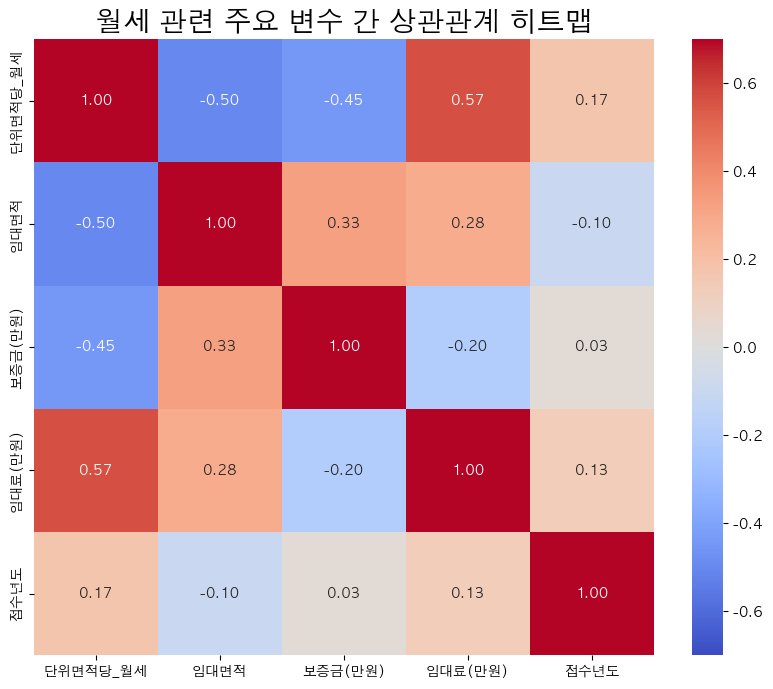

In [21]:
# 1. 수치형 변수 선택
numerical_cols = ['단위면적당_월세', '임대면적', '보증금(만원)', '임대료(만원)', '접수년도']
correlation_data = df_analysis[numerical_cols]

# 2. 상관 행렬 계산
correlation_matrix = correlation_data.corr()

# 3. 히트맵으로 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.7, vmax=0.7)
plt.title('월세 관련 주요 변수 간 상관관계 히트맵', fontsize=20)
plt.show()

### 대학가별 단위면적당 월세 분포 Violin Plot

/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_75715/1926563231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis,


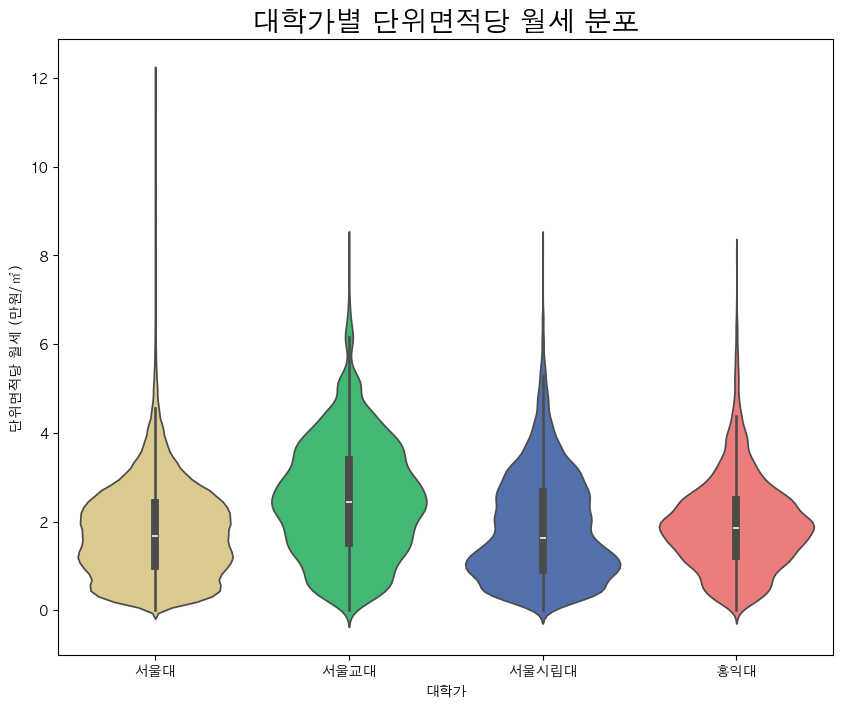

In [22]:
# plotting
plt.figure(figsize=(10, 8))
sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis, 
               palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('대학가별 단위면적당 월세 분포', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('단위면적당 월세 (만원/㎡)')
plt.show()

### 평균비교

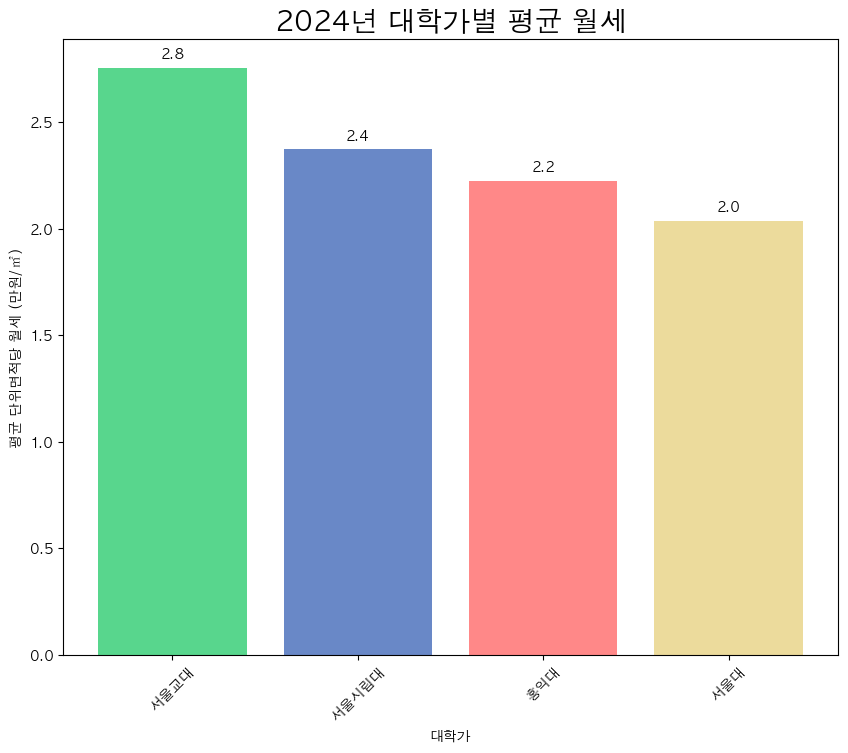

In [23]:
# 2024년 데이터 만 필터링
df_all_univ_2024 = df_analysis[df_analysis['접수년도'] == 2024]

# 평균 비교 막대그래프
plt.figure(figsize=(10, 8))
mean_by_univ = df_all_univ_2024.groupby('대학가')['단위면적당_월세'].mean().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(mean_by_univ.index, mean_by_univ.values, color=['#2ECC71', '#436BBA', '#FF6B6B', '#E8D284'], alpha=0.8)
plt.title('2024년 대학가별 평균 월세', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar, value in zip(bars, mean_by_univ.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.show()


## 신뢰도 분석

### Bootstrap

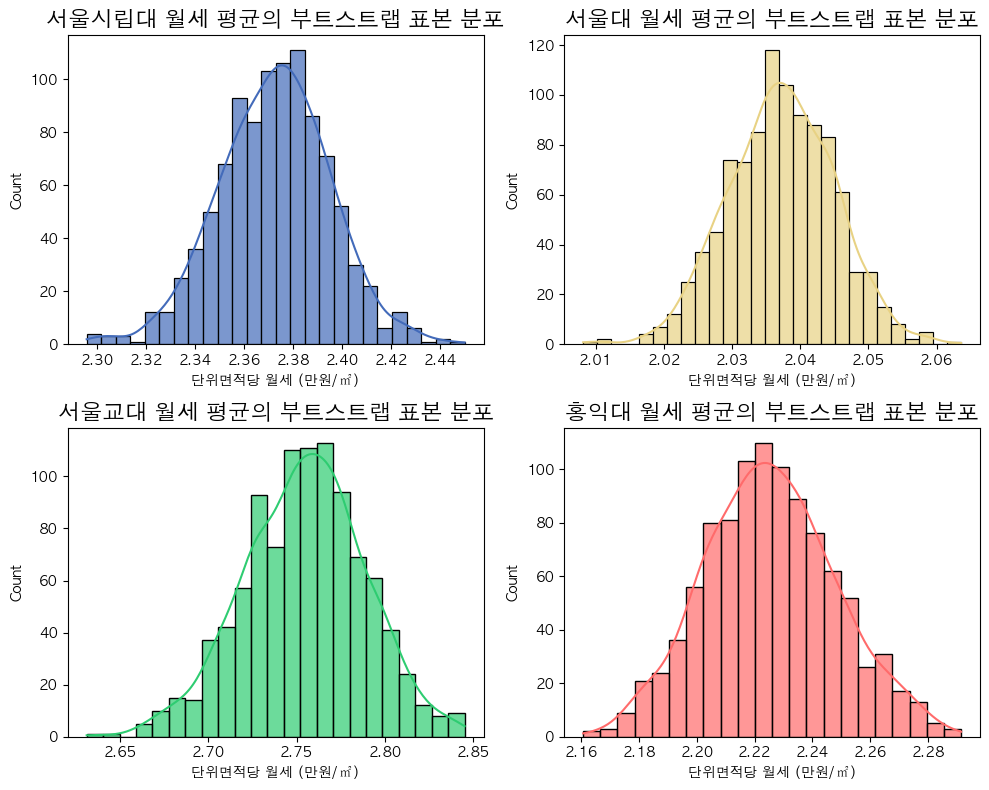

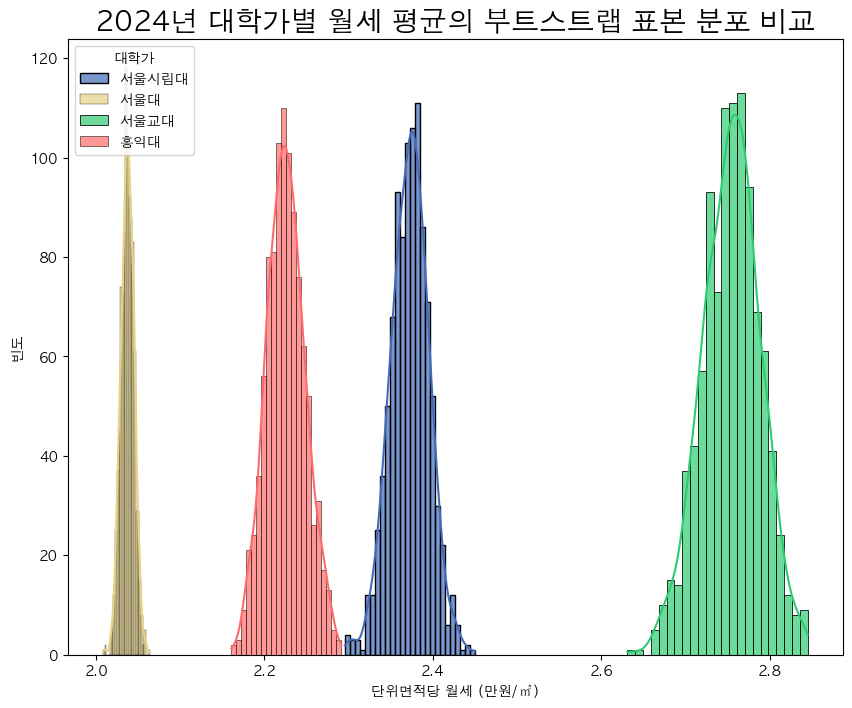

In [24]:
# 2024년 각 대학가별 데이터 분리
df_seoul_city_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울시립대']
df_seoul_nat_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울대']
df_seoul_edu_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울교대']
df_hongik_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '홍익대']

# 모든 대학가에 대해 부트스트랩 수행
universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_seoul_city_2024, df_seoul_nat_2024, 
            df_seoul_edu_2024, df_hongik_2024]
bootstrap_results = {}

for univ, data in zip(universities, datasets):
    bootstrap_means = []
    for _ in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        bootstrap_means.append(sample.mean())
    bootstrap_results[univ] = bootstrap_means

# 시각화
plt.figure(figsize=(10, 8))

colors=['#436BBA', '#E8D284', '#2ECC71', '#FF6B6B']

# 개별 대학가별 부트스트랩 분포
for i, (univ, color) in enumerate(zip(universities, colors)):
    plt.subplot(2, 2, i+1)
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, color=color)
    plt.title(f'{univ} 월세 평균의 부트스트랩 표본 분포', fontsize=16)
    plt.xlabel('단위면적당 월세 (만원/㎡)')

plt.tight_layout()
plt.show()

# 모든 대학가 부트스트랩 결과를 하나의 그래프로 비교
plt.figure(figsize=(10, 8))

for univ, color in zip(universities, colors):
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, label=univ, color=color)

plt.title('2024년 대학가별 월세 평균의 부트스트랩 표본 분포 비교', fontsize=20)
plt.xlabel('단위면적당 월세 (만원/㎡)')
plt.ylabel('빈도')
plt.legend(title='대학가')
plt.show()

### 각 대학별 95% 신뢰구간 계산

In [25]:
for univ in universities:
    bootstrap_means_univ = bootstrap_results[univ]
    
    # 95% 신뢰구간 계산
    lower_bound = np.percentile(bootstrap_means_univ, 2.5)
    upper_bound = np.percentile(bootstrap_means_univ, 97.5)
    
    # 표준오차 계산
    std_error = np.std(bootstrap_means_univ)
    
    # 평균 계산
    mean_val = np.mean(bootstrap_means_univ)
    
    print(f"=== {univ} ===")
    print(f"단위면적당 월세 평균: {mean_val:.2f} 만원")
    print(f"95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}] 만원")
    print(f"표준오차: {std_error:.2f} 만원")
    print()

=== 서울시립대 ===
단위면적당 월세 평균: 2.37 만원
95% 신뢰구간: [2.33, 2.42] 만원
표준오차: 0.02 만원

=== 서울대 ===
단위면적당 월세 평균: 2.04 만원
95% 신뢰구간: [2.02, 2.05] 만원
표준오차: 0.01 만원

=== 서울교대 ===
단위면적당 월세 평균: 2.75 만원
95% 신뢰구간: [2.68, 2.82] 만원
표준오차: 0.03 만원

=== 홍익대 ===
단위면적당 월세 평균: 2.23 만원
95% 신뢰구간: [2.18, 2.27] 만원
표준오차: 0.02 만원



### QQ plot

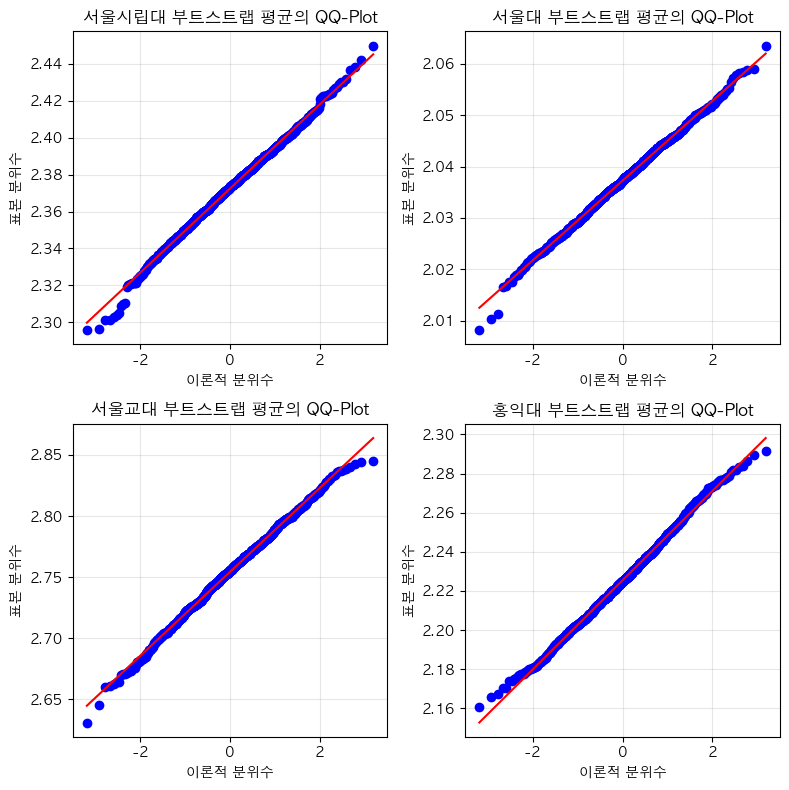

In [26]:
from scipy import stats

plt.figure(figsize=(8, 8))

# 각 대학가별 QQ-Plot
for i, univ in enumerate(universities):
    plt.subplot(2, 2, i+1)
    stats.probplot(bootstrap_results[univ], dist="norm", plot=plt)
    plt.title(f'{univ} 부트스트랩 평균의 QQ-Plot')
    plt.xlabel('이론적 분위수')
    plt.ylabel('표본 분위수')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 연도별 대학가 단위면적당 월세 변화 분석

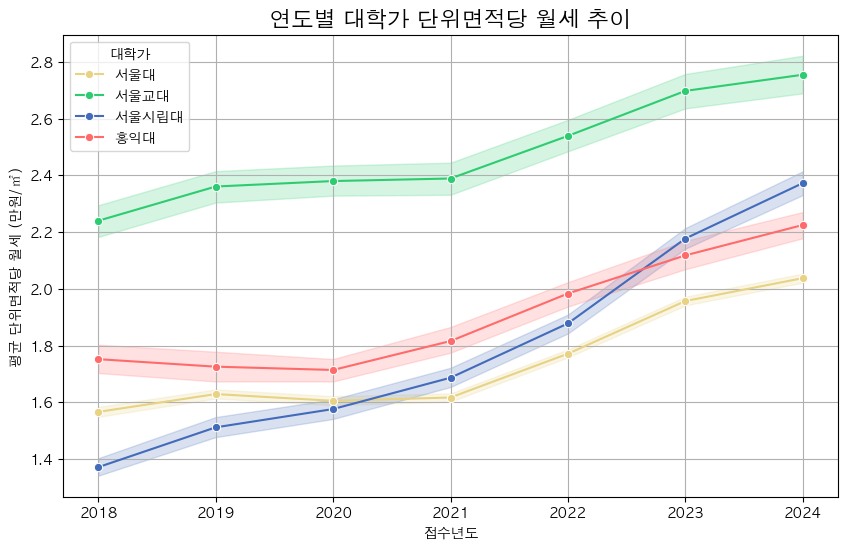

In [27]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='접수년도', y='단위면적당_월세', hue='대학가', data=df_analysis, estimator=np.mean, palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'], marker='o')
plt.title('연도별 대학가 단위면적당 월세 추이', fontsize=16)
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.grid(True)
plt.show()

### 월세 증가율

/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_75715/1788425414.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])


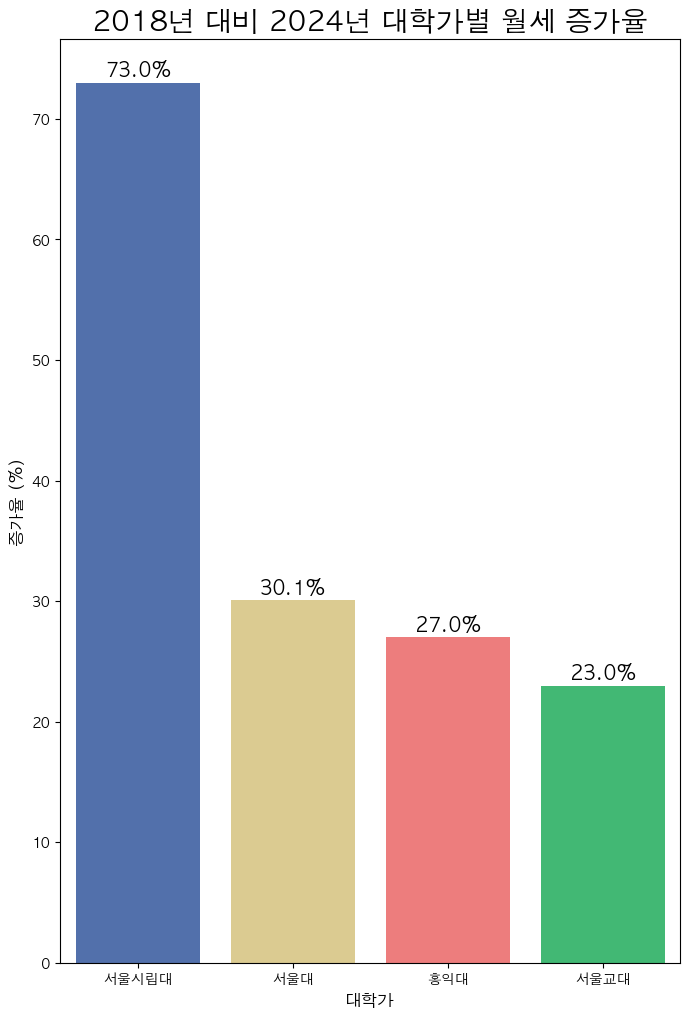

In [28]:
# 1. 증가율 계산
start_year = df_analysis['접수년도'].min()
end_year = df_analysis['접수년도'].max()

rent_start = df_analysis[df_analysis['접수년도'] == start_year].groupby('대학가')['단위면적당_월세'].mean()
rent_end = df_analysis[df_analysis['접수년도'] == end_year].groupby('대학가')['단위면적당_월세'].mean()

increase_rate = ((rent_end - rent_start) / rent_start) * 100

# 2. 증가율을 내림차순으로 정렬
sorted_increase_rate = increase_rate.sort_values(ascending=False)

# 3. 막대그래프로 시각화
plt.figure(figsize=(8, 12))
ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])

# 그래프 제목 및 축 레이블 설정
plt.title(f'{start_year}년 대비 {end_year}년 대학가별 월세 증가율', fontsize=20)
plt.ylabel('증가율 (%)', fontsize=12)
plt.xlabel('대학가', fontsize=12)
plt.xticks(rotation=0)

# 막대 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',    # 표시할 텍스트
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center', va='center',   # 정렬
                xytext=(0, 9),              # 막대 끝에서 약간 위로
                textcoords='offset points',
                fontsize=14)                
plt.show()

# Why?

## Supply-Side Analysis

### data loading

In [29]:
file_path = './Data/서울시 건축물대장 총괄표제부'
data = pd.read_csv(file_path + '.csv', encoding='cp949', low_memory=False)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19810 entries, 0 to 19809
Data columns (total 53 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   대지위치          19810 non-null  object 
 1   시군구코드명        19564 non-null  object 
 2   법정동코드명        19564 non-null  object 
 3   대지구분코드명       19810 non-null  object 
 4   주지번           19810 non-null  int64  
 5   부지번           19810 non-null  int64  
 6   특수지명          26 non-null     object 
 7   블록번호          9 non-null      object 
 8   로트번호          1 non-null      float64
 9   새주소도로코드명      12378 non-null  object 
 10  새주소법정동코드명     12378 non-null  object 
 11  새주소지상지하구분코드명  19655 non-null  object 
 12  새주소주지번        13423 non-null  float64
 13  새주소부지번        8166 non-null   float64
 14  건축물대장일련번호     19810 non-null  object 
 15  대장구분코드명       19799 non-null  object 
 16  대장종류코드명       19810 non-null  object 
 17  대지면적          12215 non-null  float64
 18  건축면적          16011 non-nu

In [31]:
data['기타용도내용']

0                                                       학교
1                                                   아파트,상가
2                                                      아파트
3                                              근린생활시설, 여인숙
4                                             아파트 및 근린생활시설
                               ...                        
19805    공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및...
19806                                숙박시설(판매,위락,문화및집회,운동등)
19807                                            공동주택(아파트)
19808                                           근린생활시설, 주택
19809                                             공동주택,아파트
Name: 기타용도내용, Length: 19810, dtype: object

In [32]:
selected_columns = ['허가일자', '새주소법정동코드명', '기타용도내용']
data = data[selected_columns]
data

,허가일자,새주소법정동코드명,기타용도내용
0,NaN,대현동,학교
1,1992-06-12,방화동,"아파트,상가"
2,1991-12-28,방화동,아파트
3,NaN,구로동,"근린생활시설, 여인숙"
4,NaN,신월동,아파트 및 근린생활시설
...,...,...,...
19805,2014-09-11,전농동,"공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및..."
19806,1986-06-02,잠실동,"숙박시설(판매,위락,문화및집회,운동등)"
19807,2004-12-24,강일동,공동주택(아파트)
19808,NaN,NaN,"근린생활시설, 주택"


In [33]:
data.isnull().sum()
data = data.dropna()
data = data.copy()


In [34]:
# '허가일자'를 날짜 형식으로 변환합니다.
# errors='coerce'는 변환할 수 없는 값이 있을 경우 오류 대신 결측치(NaT)로 만듭니다.
data['허가일자'] = pd.to_datetime(data['허가일자'], errors='coerce')

# 날짜에서 '연도'만 추출하여 새 컬럼을 만듭니다.
data['허가연도'] = data['허가일자'].dt.year

# 변환에 실패했거나 연도가 없는 데이터는 분석에서 제외합니다.
data = data.dropna(subset=['허가연도'])

# 연도를 정수형으로 변환합니다 (예: 2020.0 -> 2020).
data['허가연도'] = data['허가연도'].astype(int)

print("'허가연도' 컬럼 생성 완료:")
print(data[['허가일자', '허가연도']].head())

data

'허가연도' 컬럼 생성 완료:
         허가일자  허가연도
1  1992-06-12  1992
2  1991-12-28  1991
10 2003-12-30  2003
18 2015-09-11  2015
21 2022-02-24  2022


,허가일자,새주소법정동코드명,기타용도내용,허가연도
1,1992-06-12,방화동,"아파트,상가",1992
2,1991-12-28,방화동,아파트,1991
10,2003-12-30,장지동,아파트,2003
18,2015-09-11,항동,도시형생활주택(원룸형),2015
21,2022-02-24,공항동,공동주택(아파트),2022
...,...,...,...,...
19804,2018-10-08,원효로1가,"공동주택,제1종근린생활시설,문화및집회시설",2018
19805,2014-09-11,전농동,"공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및...",2014
19806,1986-06-02,잠실동,"숙박시설(판매,위락,문화및집회,운동등)",1986
19807,2004-12-24,강일동,공동주택(아파트),2004


In [35]:
# 1. 분류 규칙을 담은 함수를 정의합니다.
def classify_building_type(text):
    # text가 비어있는 경우(NaN)를 대비한 예외 처리
    if pd.isna(text):
        return '기타'
    
    # 1순위: '아파트' 확인
    if '아파트' in text:
        return '아파트'
    # 2순위: '오피스텔' 확인
    elif '오피스텔' in text:
        return '오피스텔'
    # 3순위: '다세대' 또는 '다가구' 확인
    elif '다세대' in text or '다가구' in text:
        return '다세대/다가구'
    # 그 외
    else:
        return '기타'

# 2. '기타용도내용' 컬럼에 함수를 적용하여 '세부용도'라는 새 컬럼을 생성합니다.
data['세부용도'] = data['기타용도내용'].apply(classify_building_type)

# 3. 분석에 필요한 주거 형태만 필터링합니다.
target_types = ['아파트', '오피스텔', '다세대/다가구']
analysis_data = data[data['세부용도'].isin(target_types)].copy()

# --- 결과 확인 ---
print("--- 분류 결과 (상위 5개) ---")
print(analysis_data[['기타용도내용', '세부용도']].head())

print("\n--- 세부용도별 데이터 개수 ---")
print(analysis_data['세부용도'].value_counts())

--- 분류 결과 (상위 5개) ---
       기타용도내용 세부용도
1      아파트,상가  아파트
2         아파트  아파트
10        아파트  아파트
21  공동주택(아파트)  아파트
23        아파트  아파트

--- 세부용도별 데이터 개수 ---
세부용도
아파트        1254
다세대/다가구     956
오피스텔        118
Name: count, dtype: int64


In [36]:
import pandas as pd


# 2. .map() 함수에 사용하기 편하도록 딕셔너리를 역으로 만듭니다.
dong_to_univ_map = {dong: univ for univ, dongs in univ_dong_map.items() for dong in dongs}

# 3. .map() 함수를 사용하여 '대학가' 컬럼을 한 번에 생성합니다.
data['대학가'] = data['새주소법정동코드명'].map(dong_to_univ_map)

# 4. '대학가' 이름이 할당되지 않은(분석 대상이 아닌) 행들을 제거하고,
#    분석용 데이터프레임을 복사본(.copy())으로 만듭니다.
analysis_data = data.dropna(subset=['대학가']).copy()


# --- 최종 결과 확인 ---
print("--- 최종 분석용 데이터 정보 ---")
analysis_data.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(analysis_data['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 ---")
# '새주소법정동코드명'이 '대학가'에 올바르게 매칭되었는지 확인합니다.
print(analysis_data[['새주소법정동코드명', '대학가']].head())

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 81 to 19809
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   허가일자       239 non-null    datetime64[ns]
 1   새주소법정동코드명  239 non-null    object        
 2   기타용도내용     239 non-null    object        
 3   허가연도       239 non-null    int64         
 4   세부용도       239 non-null    object        
 5   대학가        239 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 13.1+ KB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      132
서울교대      57
서울시립대     29
홍익대       21
Name: count, dtype: int64

--- 최종 데이터 샘플 ---
    새주소법정동코드명    대학가
81        서교동    홍익대
236      답십리동  서울시립대
422       서초동   서울교대
529       서초동   서울교대
852       신림동    서울대


In [37]:
# '허가연도', '대학가', '세부용도'를 기준으로 신축 허가 건수를 집계합니다.
supply_trend = analysis_data.groupby(['허가연도', '대학가', '세부용도']).size().reset_index(name='신축허가건수')

print("--- 연도별/대학가별/유형별 신축 허가 건수 집계 결과 ---")
print(supply_trend.head(10))

--- 연도별/대학가별/유형별 신축 허가 건수 집계 결과 ---
   허가연도  대학가     세부용도  신축허가건수
0  1983  서울대       기타       2
1  1983  홍익대       기타       1
2  1991  서울대      아파트       1
3  1992  서울대      아파트       1
4  1993  서울대  다세대/다가구       2
5  1994  서울대       기타       2
6  1994  홍익대       기타       1
7  1994  홍익대  다세대/다가구       2
8  1995  서울대       기타       2
9  1996  서울대       기타       1


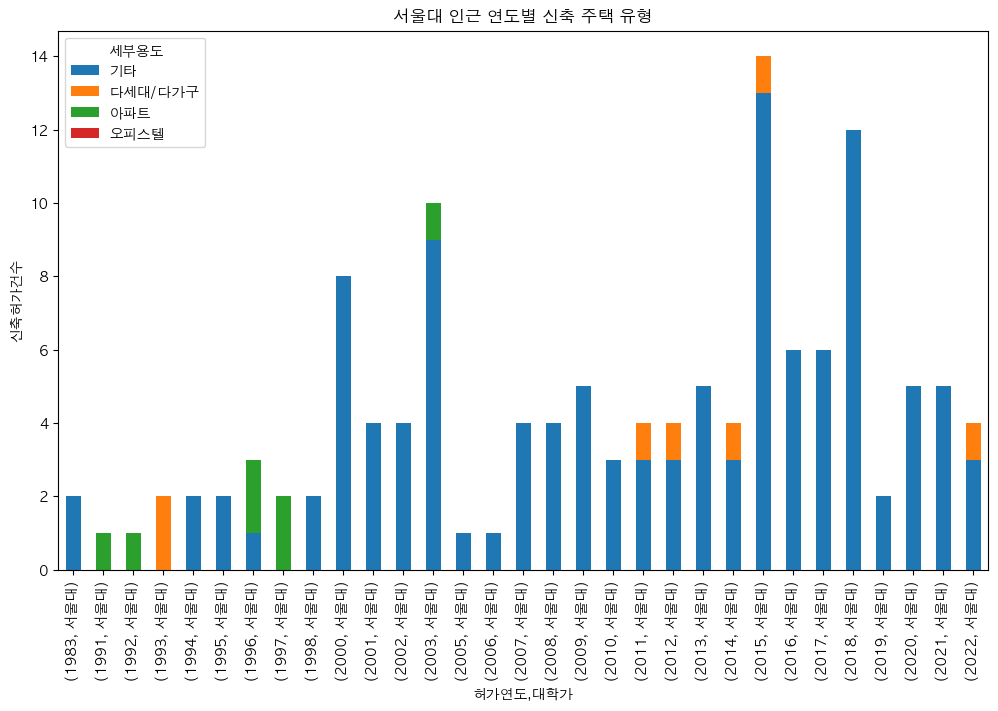

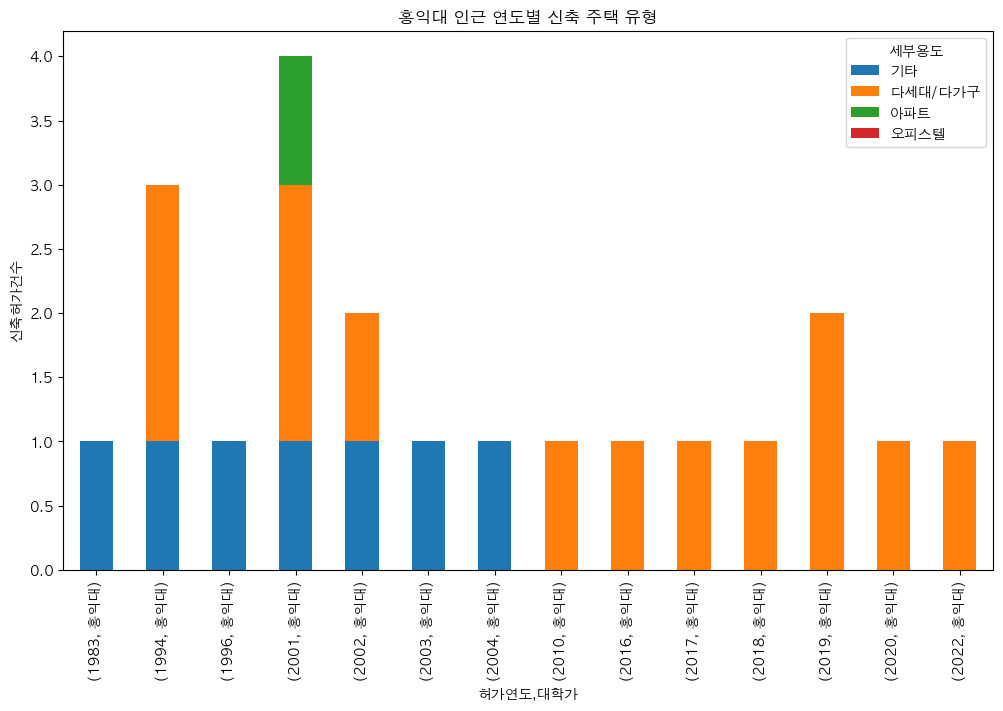

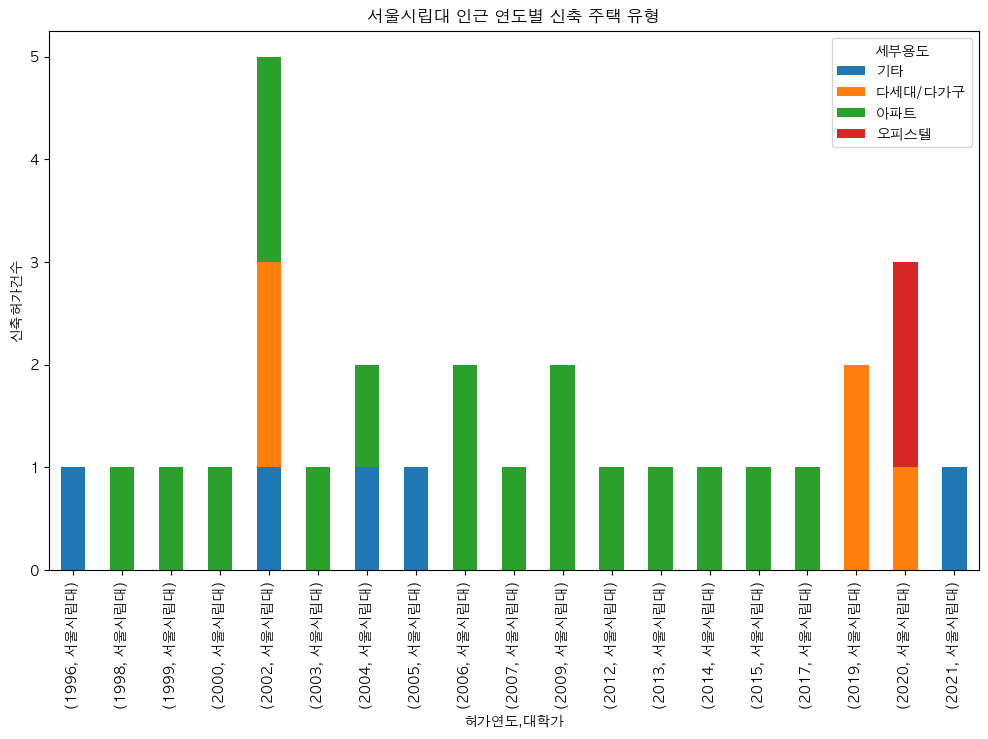

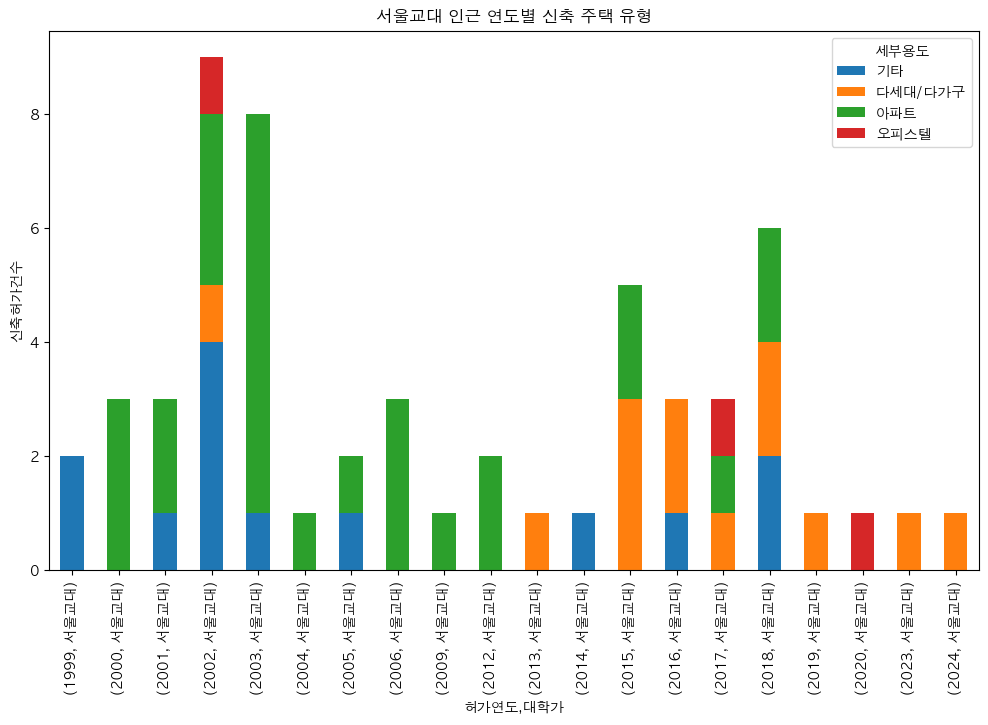

In [38]:
# 시각화를 위해 데이터를 피벗(pivot)합니다.
supply_pivot = supply_trend.pivot_table(index=['허가연도', '대학가'], 
                                        columns='세부용도', 
                                        values='신축허가건수',
                                        fill_value=0)

# 각 대학가별로 누적 막대그래프 그리기
for univ in supply_pivot.index.get_level_values('대학가').unique():
    supply_pivot.loc[(slice(None), univ), :].plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 7),
        title=f'{univ} 인근 연도별 신축 주택 유형'
    )
    plt.ylabel('신축허가건수')
    plt.show()